<a href="https://colab.research.google.com/github/Gnissan-BIA/AI-lab/blob/main/Project_part5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import libraries

In [1]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import re
import string
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import pairwise_distances_argmin_min
from sklearn.model_selection import train_test_split

import nltk
from nltk.tokenize import word_tokenize

nltk.download("punkt")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Load dataset

In [2]:
# 2. Load Newsgroups Dataset

categories = [
    "sci.space",
    "rec.sport.baseball",
    "comp.graphics",
    "talk.politics.misc"
]

newsgroups = fetch_20newsgroups(
    subset="all",
    categories=categories,
    remove=("headers", "footers", "quotes")
)

df = pd.DataFrame({
    "text": newsgroups.data,
    "target": newsgroups.target
})

df["category"] = df["target"].map(lambda x: newsgroups.target_names[x])

df.head()

,text,target,category
0,\nAre you kidding? I'm stuck with the Toronto...,1,rec.sport.baseball
1,\n\n\n\n\n\nSigh. You're absolutely right. W...,3,talk.politics.misc
2,\n\n The above statement ignores reality. The ...,3,talk.politics.misc
3,\nI'm sorry about your friend. Really. But t...,3,talk.politics.misc
4,Hank Greenberg was probably the greatest ever....,1,rec.sport.baseball


Check dataset

In [4]:
print("Dataset shape:", df.shape)
print()
print(df["category"].value_counts())

Dataset shape: (3729, 3)

category
rec.sport.baseball    994
sci.space             987
comp.graphics         973
talk.politics.misc    775
Name: count, dtype: int64


#Data Preprocessing

Basic Text Preprocessing


In [6]:
import nltk
nltk.download('punkt_tab')
def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and short words
    tokens = [
        word for word in tokens
        if word not in ENGLISH_STOP_WORDS and len(word) > 2
    ]

    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)

df[["text", "clean_text", "category"]].head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,text,clean_text,category
0,\nAre you kidding? I'm stuck with the Toronto...,kidding stuck toronto skydome idea inning stre...,rec.sport.baseball
1,\n\n\n\n\n\nSigh. You're absolutely right. W...,sigh youre absolutely right political power wh...,talk.politics.misc
2,\n\n The above statement ignores reality. The ...,statement ignores reality provoked damn phil s...,talk.politics.misc
3,\nI'm sorry about your friend. Really. But t...,sorry friend really anecdote does justify war ...,talk.politics.misc
4,Hank Greenberg was probably the greatest ever....,hank greenberg probably greatest subject lot h...,rec.sport.baseball


Train-Test Split

In [7]:
X_train, X_test = train_test_split(
    df["clean_text"],
    test_size=0.2,
    random_state=42
)

print("Training documents:", len(X_train))
print("Testing documents:", len(X_test))

Training documents: 2983
Testing documents: 746


#Text Representation

Bag of Words

In [8]:
bow_vectorizer = CountVectorizer(max_features=3000)

X_bow = bow_vectorizer.fit_transform(X_train)

print("Bag of Words shape:", X_bow.shape)

Bag of Words shape: (2983, 3000)


TF-IDF

In [9]:
tfidf_vectorizer = TfidfVectorizer(max_features=3000)

X_tfidf = tfidf_vectorizer.fit_transform(X_train)

print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (2983, 3000)


#K-Means Clustering

Apply K-Means Clustering

In [10]:
k = 4

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_tfidf)

print("Cluster labels:", np.unique(kmeans_labels))

Cluster labels: [0 1 2 3]


Evaluate K-Means Using Silhouette Score

In [11]:

sil_score = silhouette_score(X_tfidf, kmeans_labels)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.010856520125930446


# Analyze Cluster Themes

Show Top Words Per Cluster

In [12]:
terms = tfidf_vectorizer.get_feature_names_out()

def show_top_words(model, terms, n_words=15):
    for cluster_num, center in enumerate(model.cluster_centers_):
        top_indices = center.argsort()[::-1][:n_words]
        top_terms = [terms[i] for i in top_indices]

        print(f"\nCluster {cluster_num}:")
        print(", ".join(top_terms))

show_top_words(kmeans, terms)


Cluster 0:
people, just, dont, like, think, know, time, did, government, does, new, make, right, say, want

Cluster 1:
thanks, graphics, image, files, know, email, file, format, program, does, help, software, looking, bit, images

Cluster 2:
game, year, games, team, baseball, hit, players, good, think, runs, braves, dont, win, pitching, hes

Cluster 3:
space, shuttle, launch, orbit, mission, lunar, nasa, hst, think, moon, like, just, satellite, earth, solar


#Visualize Clusters with PCA

Reduce TF-IDF Features to 2D Using PCA


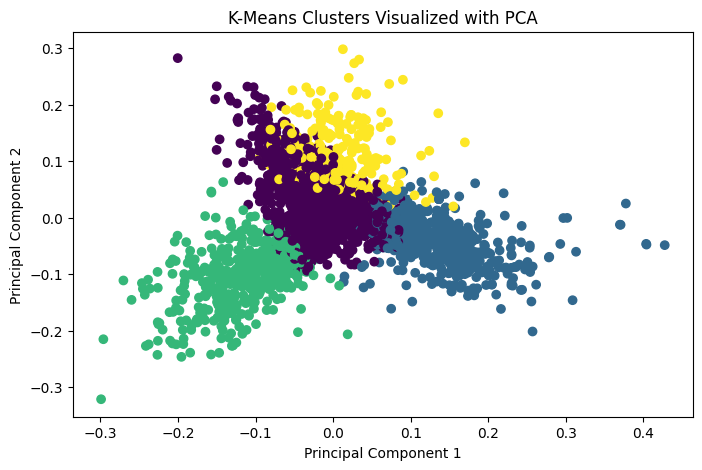

In [13]:
X_dense = X_tfidf.toarray()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

#Hierarchical Clustering

Apply Hierarchical Clustering

In [14]:

# Using smaller sample because hierarchical clustering can be slow
sample_size = 500

X_sample = X_tfidf[:sample_size].toarray()

hierarchical = AgglomerativeClustering(n_clusters=4)

hierarchical_labels = hierarchical.fit_predict(X_sample)

print("Hierarchical cluster labels:", np.unique(hierarchical_labels))

Hierarchical cluster labels: [0 1 2 3]


Evaluate Hierarchical Clustering

In [15]:

hier_sil_score = silhouette_score(X_sample, hierarchical_labels)

print("Hierarchical Silhouette Score:", hier_sil_score)

Hierarchical Silhouette Score: 0.013218559086456586


#Word Embeddings

Simple Pre-trained Word Embedding

In [17]:
!pip install gensim
import gensim.downloader as api

word_vectors = api.load("glove-wiki-gigaword-50")

print(word_vectors.most_similar("space", topn=5))
print(word_vectors.most_similar("baseball", topn=5))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 59.0 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
[('earth', 0.7598934769630432), ('shuttle', 0.739173173904419), ('orbit', 0.7259402871131897), ('solar', 0.7221783995628357), ('planet', 0.7160946726799011)]
[('basketball', 0.8613373637199402), ('nba', 0.8525449633598328), ('nfl', 0.8311336040496826), ('football', 0.7990508079528809), ('leagues', 0.7907131910324097)]


New Unseen Documents


In [18]:

new_documents = [
    "NASA launched a new satellite to study planets and space exploration.",
    "The baseball team won the championship after a strong final inning.",
    "Computer graphics are used to create realistic 3D images and animations.",
    "The government debated new political policies in parliament."
]

# Preprocess new documents
new_documents_clean = [preprocess_text(doc) for doc in new_documents]

# Transform using trained TF-IDF vectorizer
new_documents_tfidf = tfidf_vectorizer.transform(new_documents_clean)

# Predict clusters
new_clusters = kmeans.predict(new_documents_tfidf)

for doc, cluster in zip(new_documents, new_clusters):
    print("\nDocument:")
    print(doc)
    print("Predicted Cluster:", cluster)


Document:
NASA launched a new satellite to study planets and space exploration.
Predicted Cluster: 3

Document:
The baseball team won the championship after a strong final inning.
Predicted Cluster: 2

Document:
Computer graphics are used to create realistic 3D images and animations.
Predicted Cluster: 1

Document:
The government debated new political policies in parliament.
Predicted Cluster: 0


Cohesion and Separation

Cohesion: Distance of Documents to Their Cluster Centers

In [19]:

closest, distances = pairwise_distances_argmin_min(
    X_tfidf,
    kmeans.cluster_centers_
)

print("Average distance to cluster center:", np.mean(distances))

Average distance to cluster center: 0.9497867408132987


# 16. Cluster Size Analysis

0    1685
1     562
2     455
3     281
Name: count, dtype: int64


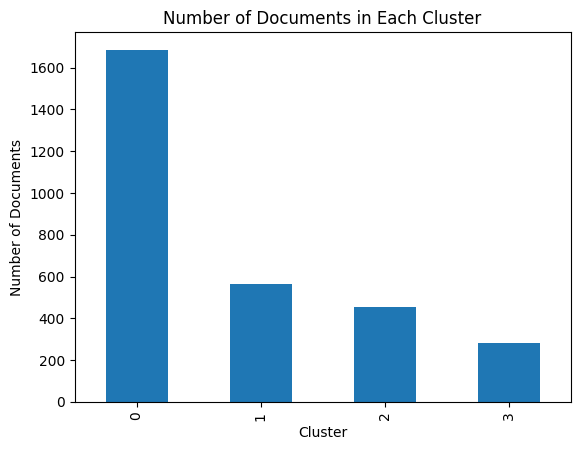

In [20]:
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()

print(cluster_counts)

cluster_counts.plot(kind="bar")
plt.title("Number of Documents in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Documents")
plt.show()